# Objectives
The primary objectives of this lab were to:

1. **Perform Exploratory Data Analysis (EDA):**  
   - Gain insights into the dataset by analyzing univariate, bivariate, and multivariate relationships.  
   - Use visualizations such as histograms, scatter plots, box plots, pair plots, and heatmaps to identify patterns, correlations, and anomalies.

2. **Handle Missing Values:**  
   - Identify missing values and implement appropriate methods (e.g., imputation) to handle them effectively while preserving data integrity.

3. **Identify and Handle Outliers:**  
   - Detect outliers in numerical columns using visualizations and statistical methods (IQR).  
   - Implement approaches like percentile capping and log transformations to address outliers while minimizing data loss.

4. **Enhance Data Visualizations:**  
   - Improve visual clarity by adding axis labels, titles, and data annotations to plots.  
   - Explore advanced visualizations (e.g., violin plots and heatmaps) to analyze relationships across categorical and numerical variables.

5. **Handle Special Values ('Unknown'):**  
   - Identify and decide how to treat 'unknown' values in categorical columns.  
   - Justify the approach based on the data's context and its impact on analysis.

6. **Analyze Relationships Across Variables:**  
   - Compare relationships between numerical, categorical, and multivariate data.  
   - Draw insights from graphs like response rates across loan status, education levels, and marital statuses.

## **Example 1: Loading Data**

In [8]:
# Import the useful libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Read the data set of "Marketing Analysis" in data.
marketing_data = pd.read_csv("marketing_analysis.csv")

# Print the data
marketing_data

/var/folders/qc/ylrp4vq57n590bhgm999r9fw0000gn/T/ipykernel_55828/1135919472.py:9: DtypeWarning: Columns (0,1,2,3,11,14,15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  marketing_data = pd.read_csv("marketing_analysis.csv")


,banking marketing,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18
0,customer id and age.,NaN,Customer salary and balance.,NaN,Customer marital status and job with education...,NaN,particular customer before targeted or not,NaN,Loan types: loans or housing loans,NaN,Contact type,NaN,month of contact,duration of call,NaN,NaN,NaN,outcome of previous contact,response of customer after call happned
1,customerid,age,salary,balance,marital,jobedu,targeted,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,response
2,1,58,100000,2143,married,"management,tertiary",yes,no,yes,no,unknown,5,"may, 2017",261 sec,1,-1,0,unknown,no
3,2,44,60000,29,single,"technician,secondary",yes,no,yes,no,unknown,5,"may, 2017",151 sec,1,-1,0,unknown,no
4,3,33,120000,2,married,"entrepreneur,secondary",yes,no,yes,yes,unknown,5,"may, 2017",76 sec,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45208,45207,51.0,60000,825,married,"technician,tertiary",yes,no,no,no,cellular,17,"nov, 2017",16.2833333333333 min,3,-1,0,unknown,yes
45209,45208,71.0,55000,1729,divorced,"retired,primary",yes,no,no,no,cellular,17,"nov, 2017",7.6 min,2,-1,0,unknown,yes
45210,45209,72.0,55000,5715,married,"retired,secondary",yes,no,no,no,cellular,17,"nov, 2017",18.7833333333333 min,5,184,3,success,yes
45211,45210,57.0,20000,668,married,"blue-collar,secondary",yes,no,no,no,telephone,17,"nov, 2017",8.46666666666667 min,4,-1,0,unknown,no


## **Example 2: Skipping Rows for Clean Data Loading**

In [9]:
# Read the file without the first two rows as they are of no use
marketing_data = pd.read_csv("marketing_analysis.csv", skiprows=2)

# Print the head of the data frame
marketing_data.head()

,customerid,age,salary,balance,marital,jobedu,targeted,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,response
0,1,58.0,100000,2143,married,"management,tertiary",yes,no,yes,no,unknown,5,"may, 2017",261 sec,1,-1,0,unknown,no
1,2,44.0,60000,29,single,"technician,secondary",yes,no,yes,no,unknown,5,"may, 2017",151 sec,1,-1,0,unknown,no
2,3,33.0,120000,2,married,"entrepreneur,secondary",yes,no,yes,yes,unknown,5,"may, 2017",76 sec,1,-1,0,unknown,no
3,4,47.0,20000,1506,married,"blue-collar,unknown",no,no,yes,no,unknown,5,"may, 2017",92 sec,1,-1,0,unknown,no
4,5,33.0,0,1,single,"unknown,unknown",no,no,no,no,unknown,5,"may, 2017",198 sec,1,-1,0,unknown,no


## **Example 3: Data Cleaning: Dropping Columns**

In [10]:
# Drop the customer id as it is of no use.
marketing_data.drop('customerid', axis=1, inplace=True)

## **Example 4: Data Cleaning: Splitting Columns**

In [11]:
# Extract job & Education in newly from "jobedu" column.
marketing_data['job'] = marketing_data['jobedu'].apply(lambda x: x.split(",")[0])
marketing_data['education'] = marketing_data['jobedu'].apply(lambda x: x.split(",")[1])

# Drop the "jobedu" column from the data frame
marketing_data.drop('jobedu', axis=1, inplace=True)

# Print the dataset
marketing_data

,age,salary,balance,marital,targeted,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,response,job,education
0,58.0,100000,2143,married,yes,no,yes,no,unknown,5,"may, 2017",261 sec,1,-1,0,unknown,no,management,tertiary
1,44.0,60000,29,single,yes,no,yes,no,unknown,5,"may, 2017",151 sec,1,-1,0,unknown,no,technician,secondary
2,33.0,120000,2,married,yes,no,yes,yes,unknown,5,"may, 2017",76 sec,1,-1,0,unknown,no,entrepreneur,secondary
3,47.0,20000,1506,married,no,no,yes,no,unknown,5,"may, 2017",92 sec,1,-1,0,unknown,no,blue-collar,unknown
4,33.0,0,1,single,no,no,no,no,unknown,5,"may, 2017",198 sec,1,-1,0,unknown,no,unknown,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51.0,60000,825,married,yes,no,no,no,cellular,17,"nov, 2017",16.2833333333333 min,3,-1,0,unknown,yes,technician,tertiary
45207,71.0,55000,1729,divorced,yes,no,no,no,cellular,17,"nov, 2017",7.6 min,2,-1,0,unknown,yes,retired,primary
45208,72.0,55000,5715,married,yes,no,no,no,cellular,17,"nov, 2017",18.7833333333333 min,5,184,3,success,yes,retired,secondary
45209,57.0,20000,668,married,yes,no,no,no,telephone,17,"nov, 2017",8.46666666666667 min,4,-1,0,unknown,no,blue-collar,secondary


## **Example 5: Handling Missing Values**

In [12]:
# Check for missing values in the dataset
marketing_data.isnull().sum()

age          20
salary        0
balance       0
marital       0
targeted      0
default       0
housing       0
loan          0
contact       0
day           0
month        50
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
response     30
job           0
education     0
dtype: int64

## **Example 6: Handling Missing Values: Example for Imputation**

In [13]:
# Dropping the records with age missing in the data dataframe.
marketing_data = marketing_data[~marketing_data.age.isnull()].copy()

# Checking the missing values in the dataset.
marketing_data.isnull().sum()

age           0
salary        0
balance       0
marital       0
targeted      0
default       0
housing       0
loan          0
contact       0
day           0
month        50
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
response     30
job           0
education     0
dtype: int64

In [14]:
# Find the mode of the month in the data.
month_mode = marketing_data.month.mode()[0]

# Fill the missing values with the mode value of the month in data.
marketing_data.month.fillna(month_mode, inplace=True)

# Check if missing values in the month column are handled.
marketing_data.isnull().sum()

/var/folders/qc/ylrp4vq57n590bhgm999r9fw0000gn/T/ipykernel_55828/1776000319.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  marketing_data.month.fillna(month_mode, inplace=True)


age           0
salary        0
balance       0
marital       0
targeted      0
default       0
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
response     30
job           0
education     0
dtype: int64

## **Question 1: Handle Missing Values Using Alternative Approaches**

**Task**: Implement **three alternative approaches** to handle missing values in the **`age`** and/or **`month`** columns. Ensure these methods are different from the ones demonstrated in the examples (e.g., mode imputation or row deletion for `age

### **Approach 1: Median Imputation for Numerical Column (`age`)**

**Why this approach?**  
The median is less sensitive to outliers compared to the mean, making it a robust measure for imputing missing values in numerical columns. Since the `age` column may contain outliers (e.g., extremely high or low values), using the median ensures the imputed values represent the central tendency of the data without being skewed.

In [15]:
# Approach 1: Median Imputation for 'age'
age_median = marketing_data['age'].median()
marketing_data['age'] = marketing_data['age'].fillna(age_median)

# Check for missing values
print("Missing values after median imputation:")
print(marketing_data.isnull().sum())

Missing values after median imputation:
age           0
salary        0
balance       0
marital       0
targeted      0
default       0
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
response     30
job           0
education     0
dtype: int64


### **Approach 2: Constant Value Imputation for Categorical Column (`month`)**

**Why this approach?**  
For categorical data like `month`, imputing with a constant value such as `'unknown'` preserves all rows in the dataset while clearly indicating that the value is missing. This approach is especially useful when the missing data cannot be imputed meaningfully and avoids introducing bias.

In [16]:
# Approach 2: Constant value imputation for 'month'
marketing_data['month'] = marketing_data['month'].fillna('unknown')

# Check for missing values
print("Missing values after constant value imputation:")
print(marketing_data.isnull().sum())

Missing values after constant value imputation:
age           0
salary        0
balance       0
marital       0
targeted      0
default       0
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
response     30
job           0
education     0
dtype: int64


### **Approach 3: Forward Fill (ffill) for Temporal Consistency**

**Why this approach?**  
Forward fill (`ffill`) is particularly useful when the missing values in a column, such as `age` or `month`, follow a temporal sequence or order. It propagates the last valid observation forward, maintaining the data’s temporal integrity. This approach works well when missing values are likely to be similar to their preceding values.

In [17]:
# Approach 3: Forward fill for 'age'
marketing_data['age'] = marketing_data['age'].ffill()

# Check for missing values
print("Missing values after forward fill:")
print(marketing_data.isnull().sum())

Missing values after forward fill:
age           0
salary        0
balance       0
marital       0
targeted      0
default       0
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
response     30
job           0
education     0
dtype: int64


### **Summary of Approaches:**

1. **Median Imputation**:
   - Suitable for numerical columns with outliers (e.g., `age`).
   - Ensures central tendency is maintained without being influenced by extreme values.

2. **Constant Value Imputation**:
   - Effective for categorical columns like `month` when no meaningful imputation is possible.
   - Makes missing values explicit (e.g., `'unknown'`), avoiding ambiguity.

3. **Forward Fill (ffill)**:
   - Useful for sequential or time-ordered data where missing values are likely to resemble previous observations.
   - Preserves the temporal consistency of the dataset.

In [18]:
# Drop the records with response missing in data.
marketing_data = marketing_data[~marketing_data.response.isnull()].copy()

# Calculate the missing values in each column of data frame
marketing_data.isnull().sum()

age          0
salary       0
balance      0
marital      0
targeted     0
default      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
response     0
job          0
education    0
dtype: int64

## **Question 2: Identify and Handle Outliers**

**Task**:  Is there outliers in our dataset? If yes, implement an approach to handle them. If no, demonstrate how you made this conclusion. If they exist:

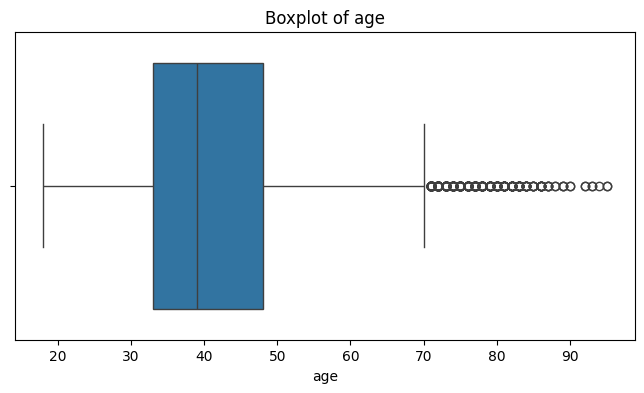

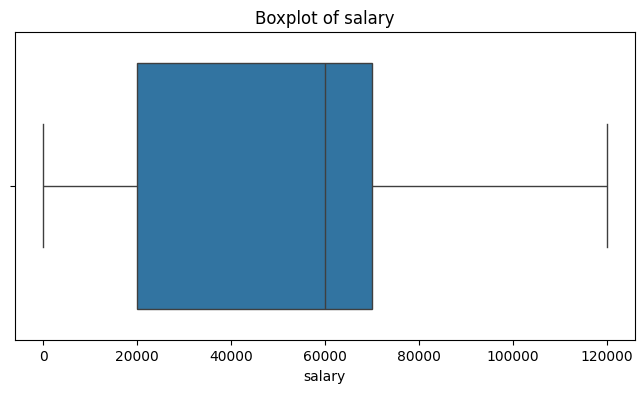

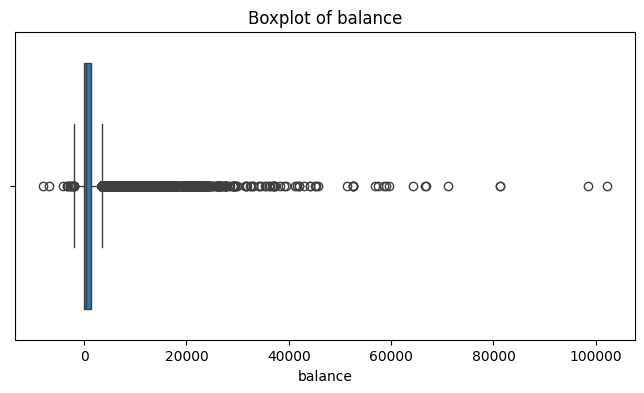

Number of outliers in each numeric column:
age: 487
salary: 0
balance: 4726


In [19]:
# Visualizing potential outliers using boxplots
numeric_columns = ['age', 'salary', 'balance']

for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=marketing_data, x=column)
    plt.title(f'Boxplot of {column}')
    plt.show()

# Using IQR to detect outliers for each numeric column
outlier_summary = {}
for column in numeric_columns:
    Q1 = marketing_data[column].quantile(0.25)
    Q3 = marketing_data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = marketing_data[(marketing_data[column] < lower_bound) | (marketing_data[column] > upper_bound)]
    outlier_summary[column] = len(outliers)

# Display the number of outliers for each column
print("Number of outliers in each numeric column:")
for col, count in outlier_summary.items():
    print(f"{col}: {count}")

**Observations:**

- **`age`:** 487 outliers detected.
- **`salary`:** 0 outliers detected.
- **`balance`:** 4,726 outliers detected.

**Conclusion:** There are significant numbers of outliers in the `age` and `balance` columns, while `salary` appears to have no outliers.

#### **Step 2: Handling Outliers**

Given the presence of outliers in `age` and `balance`, we'll implement appropriate methods to handle them while justifying our choices.

---

##### **Handling Outliers in `age`**

**Visualize the Distribution:**

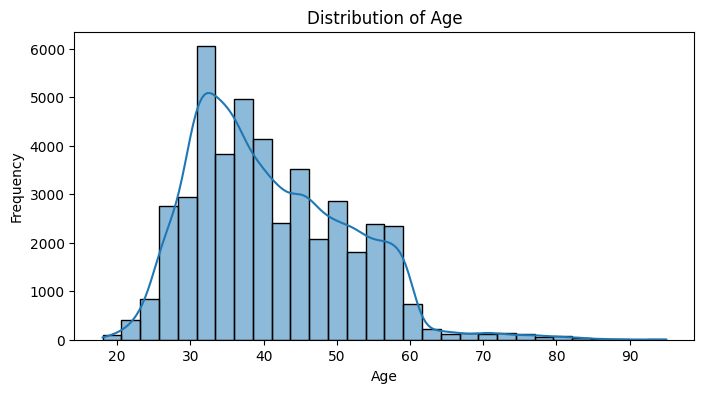

In [20]:
# Histogram of age
plt.figure(figsize=(8, 4))
sns.histplot(marketing_data['age'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

**Approach:** **Percentile Capping (Winsorization)**

- **Why:** Capping extreme values at certain percentiles reduces the impact of outliers without removing data points.
- **Implementation:** Cap `age` at the 1st and 99th percentiles.

In [21]:
# Calculate the 1st and 99th percentiles
lower_cap = marketing_data['age'].quantile(0.01)
upper_cap = marketing_data['age'].quantile(0.99)

# Apply capping
marketing_data['age'] = np.where(marketing_data['age'] < lower_cap, lower_cap, marketing_data['age'])
marketing_data['age'] = np.where(marketing_data['age'] > upper_cap, upper_cap, marketing_data['age'])


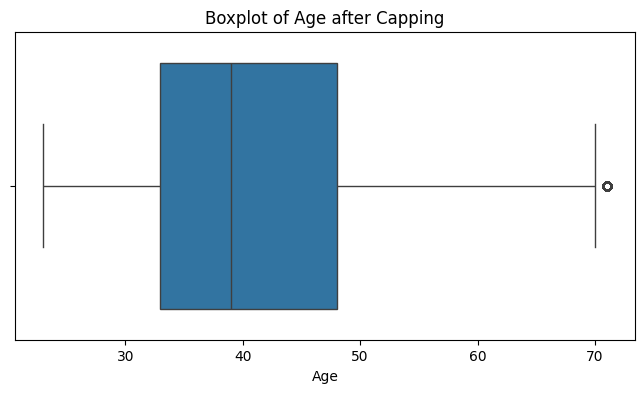

In [22]:
# Verify the Effect: Boxplot after capping
plt.figure(figsize=(8, 4))
sns.boxplot(data=marketing_data, x='age')
plt.title('Boxplot of Age after Capping')
plt.xlabel('Age')
plt.show()


##### **Handling Outliers in `balance`**

**Visualize the Distribution:**

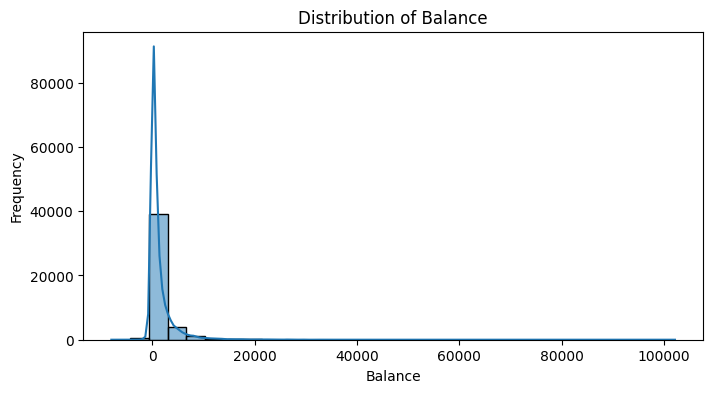

In [23]:
# Histogram of balance
plt.figure(figsize=(8, 4))
sns.histplot(marketing_data['balance'], bins=30, kde=True)
plt.title('Distribution of Balance')
plt.xlabel('Balance')
plt.ylabel('Frequency')
plt.show()

**Observation:** The `balance` distribution is skewed to the right with many extreme values.

**Approach:** **Log Transformation with Capping**

- **Why:** Log transformation reduces skewness, making the data more normally distributed. Capping after transformation handles residual outliers.
- **Implementation:**
  - Shift `balance` to positive values (if necessary).
  - Apply log transformation.
  - Cap transformed values at appropriate bounds.

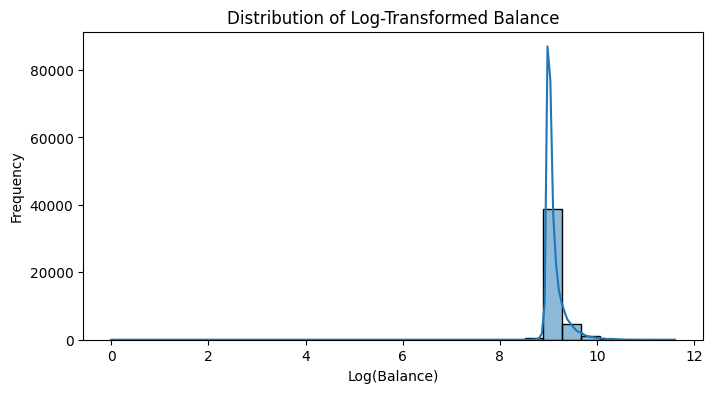

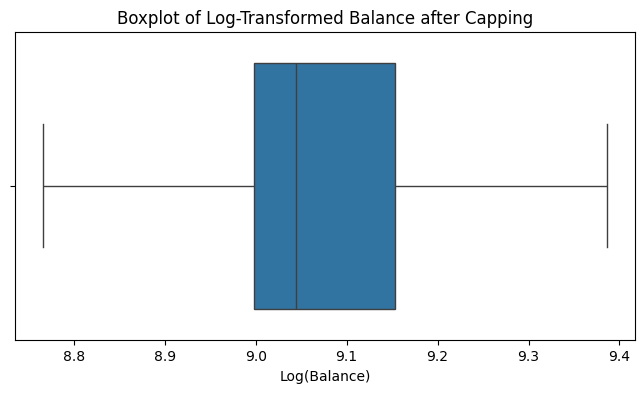

In [24]:
# Shift balance to ensure all values are positive
min_balance = marketing_data['balance'].min()
shift_value = abs(min_balance) + 1  # Add 1 to handle zero values
marketing_data['balance_shifted'] = marketing_data['balance'] + shift_value

# Apply log transformation
marketing_data['balance_log'] = np.log(marketing_data['balance_shifted'])

# Visualize the transformed distribution
plt.figure(figsize=(8, 4))
sns.histplot(marketing_data['balance_log'], bins=30, kde=True)
plt.title('Distribution of Log-Transformed Balance')
plt.xlabel('Log(Balance)')
plt.ylabel('Frequency')
plt.show()

# Detect outliers in the transformed data
Q1 = marketing_data['balance_log'].quantile(0.25)
Q3 = marketing_data['balance_log'].quantile(0.75)
IQR = Q3 - Q1
lower_bound_log = Q1 - 1.5 * IQR
upper_bound_log = Q3 + 1.5 * IQR

# Cap the transformed outliers
marketing_data['balance_log'] = np.where(marketing_data['balance_log'] < lower_bound_log, lower_bound_log, marketing_data['balance_log'])
marketing_data['balance_log'] = np.where(marketing_data['balance_log'] > upper_bound_log, upper_bound_log, marketing_data['balance_log'])

# Verify the effect
plt.figure(figsize=(8, 4))
sns.boxplot(data=marketing_data, x='balance_log')
plt.title('Boxplot of Log-Transformed Balance after Capping')
plt.xlabel('Log(Balance)')
plt.show()


#### **Justification of Approaches**

- **Age (Percentile Capping):**
  - **Preserves Data Integrity:** Does not remove any records.
  - **Reduces Outlier Impact:** Limits the influence of extreme age values that may skew analysis.
  - **Realistic Bounds:** Caps are set based on data percentiles, ensuring values remain within plausible human age ranges.

- **Balance (Log Transformation with Capping):**
  - **Addresses Skewness:** Log transformation normalizes the distribution, making it suitable for modeling.
  - **Handles Wide Value Range:** Reduces the effect of very large balances.
  - **Combines Methods:** Capping after transformation further minimizes the impact of extreme values.

---

#### **Final Verification**

**Re-plot Distributions and Boxplots:**

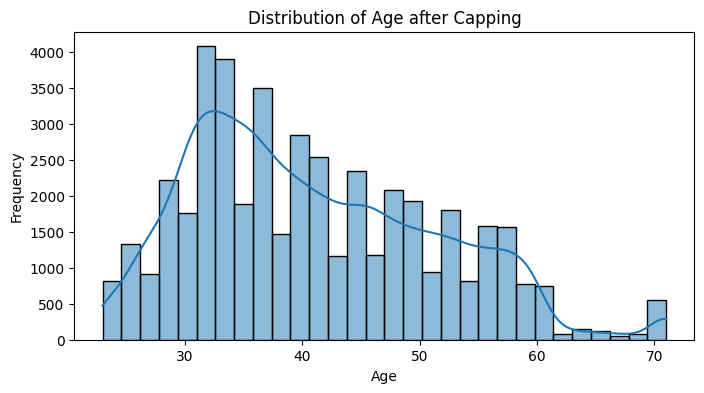

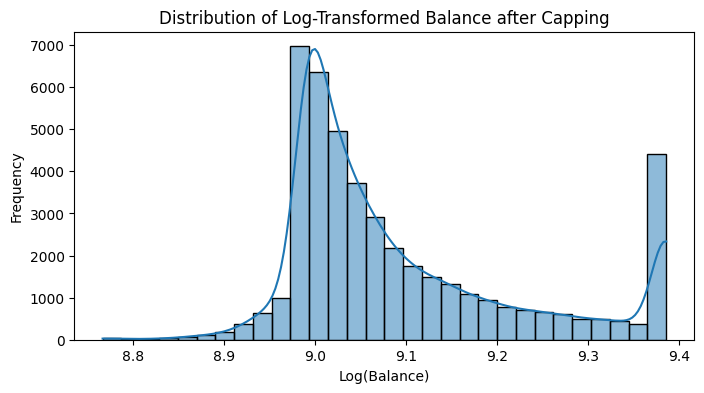

In [25]:
# Age Distribution after Capping
plt.figure(figsize=(8, 4))
sns.histplot(marketing_data['age'], bins=30, kde=True)
plt.title('Distribution of Age after Capping')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Log-Transformed Balance Distribution after Capping
plt.figure(figsize=(8, 4))
sns.histplot(marketing_data['balance_log'], bins=30, kde=True)
plt.title('Distribution of Log-Transformed Balance after Capping')
plt.xlabel('Log(Balance)')
plt.ylabel('Frequency')
plt.show()


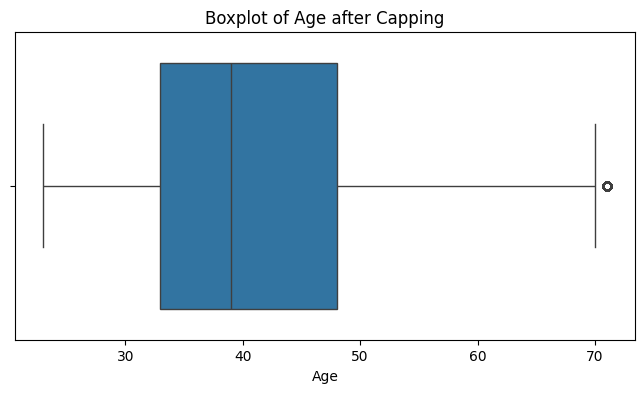

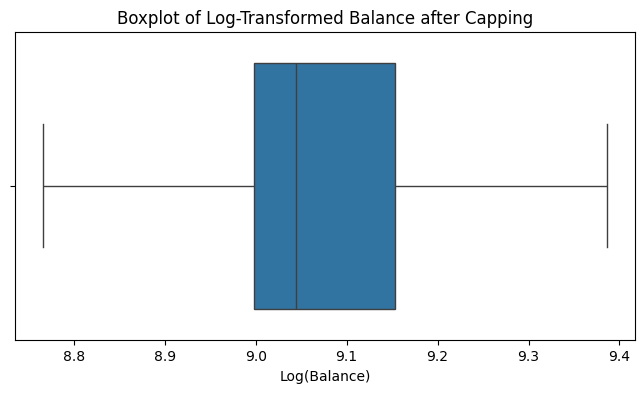

In [26]:
# Boxplot of Age after Capping
plt.figure(figsize=(8, 4))
sns.boxplot(x=marketing_data['age'])
plt.title('Boxplot of Age after Capping')
plt.xlabel('Age')
plt.show()

# Boxplot of Log-Transformed Balance after Capping
plt.figure(figsize=(8, 4))
sns.boxplot(x=marketing_data['balance_log'])
plt.title('Boxplot of Log-Transformed Balance after Capping')
plt.xlabel('Log(Balance)')
plt.show()


#### **Conclusion**

- **Outliers were identified** in the `age` and `balance` columns.
- **Handled Outliers by:**
  - **Age:** Capping at the 1st and 99th percentiles to reduce the influence of extreme ages while retaining all data points.
  - **Balance:** Applying log transformation to normalize the distribution, followed by capping to address remaining outliers.
- **Justification:**
  - **Data Preservation:** Methods avoid dropping data, which is crucial for maintaining dataset size and representativeness.
  - **Statistical Appropriateness:** Techniques are standard practices for handling skewed data and outliers.
- **Next Steps:** Proceed with analysis using the adjusted `age` and `balance_log` variables for more accurate modeling and insights.

## **Example 7: Univariate Analysis: Categorical Unordered Variables**

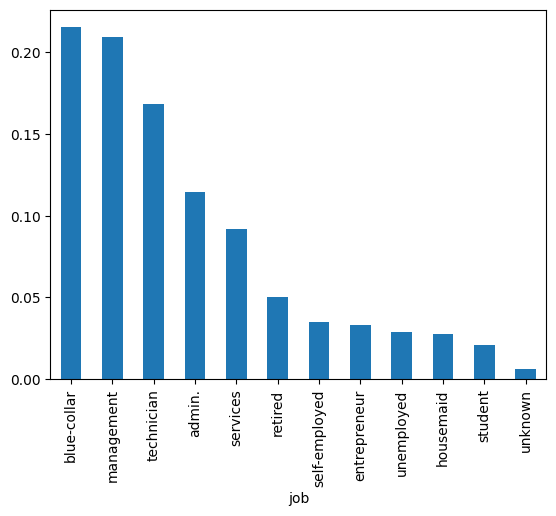

In [27]:
# Calculate the percentage of each job status category.
marketing_data.job.value_counts(normalize=True)

# Plot the bar graph of percentage job categories.
marketing_data.job.value_counts(normalize=True).plot.bar()
plt.show()

## **Question 3: Enhance Data Visualizations**

**Task**: Add titles and data labels to the plot.


### Key Enhancements
1. **Title**:
   - `plt.title()` clearly describes the content of the plot.
   - Added formatting for emphasis.
2. **Axis Labels**:
   - `plt.xlabel()` and `plt.ylabel()` provide clarity on what the axes represent.
3. **Data Labels**:
   - `plt.text()` adds exact percentages above the bars for better readability.
4. **Formatting**:
   - Adjusted figure size and text alignment for a polished look.
   - Used color and edge styling for bars.

### Result
This enhanced visualization ensures that the graph is self-explanatory and visually engaging, making it easier for stakeholders to interpret the data without additional explanations.

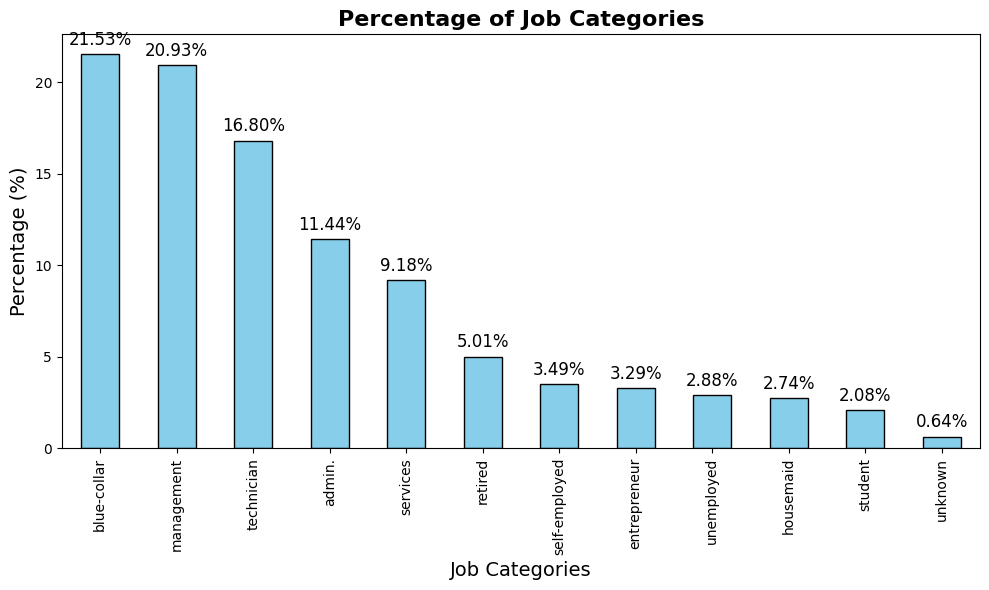

In [28]:
# Calculate the percentage of each job status category
job_percentage = marketing_data.job.value_counts(normalize=True) * 100

# Plot the bar graph of job categories
plt.figure(figsize=(10, 6))
ax = job_percentage.plot.bar(color='skyblue', edgecolor='black')

# Add title and labels
plt.title('Percentage of Job Categories', fontsize=16, fontweight='bold')
plt.xlabel('Job Categories', fontsize=14)
plt.ylabel('Percentage (%)', fontsize=14)

# Add data labels on top of each bar
for i, value in enumerate(job_percentage):
    plt.text(i, value + 0.5, f'{value:.2f}%', ha='center', fontsize=12, color='black')

# Show the plot
plt.tight_layout()
plt.show()


## **Question 4: Handle 'Unknown' Values in the Dataset**

**Task**: There are 'unknown' values in the dataset. Should we consider them missing? Explain how you would handle them, and demonstrate your solution. If you decide to leave them as they are, explain why you made this decision.

### **Analysis**

To determine if 'unknown' values should be treated as missing data:
1. **Check for 'unknown' Values**:
   - Use `.isin(['unknown']).sum()` to count the occurrences of 'unknown' in each column.
   - This step helps identify where the data is incomplete or unspecified.
   
2. **Importance of Columns**:
   - **Critical Columns**: For columns like `job` and `education`, 'unknown' values impact the integrity of analysis as they represent key demographic details.
   - **Non-Critical Columns**: Columns like `contact` and `poutcome` are interaction-based and may not require replacement.

---

### **Steps to Handle 'Unknown' Values**


In [29]:
# Step 1: Identify Columns with 'unknown' Values
# Check for 'unknown' values in the dataset
unknown_counts = marketing_data.isin(['unknown']).sum()
print("Counts of 'unknown' values in each column:")
print(unknown_counts)

Counts of 'unknown' values in each column:
age                    0
salary                 0
balance                0
marital                0
targeted               0
default                0
housing                0
loan                   0
contact            13002
day                    0
month                  0
duration               0
campaign               0
pdays                  0
previous               0
poutcome           36920
response               0
job                  288
education           1856
balance_shifted        0
balance_log            0
dtype: int64


In [30]:
# Step 2: Replace 'unknown' in Key Columns
# Replace 'unknown' in 'job' and 'education' with the mode of the column
marketing_data['job'] = marketing_data['job'].replace('unknown', marketing_data['job'].mode()[0])
marketing_data['education'] = marketing_data['education'].replace('unknown', marketing_data['education'].mode()[0])

# Verify that 'unknown' values have been handled
print("Counts of 'unknown' values after handling:")
print(marketing_data.isin(['unknown']).sum())


Counts of 'unknown' values after handling:
age                    0
salary                 0
balance                0
marital                0
targeted               0
default                0
housing                0
loan                   0
contact            13002
day                    0
month                  0
duration               0
campaign               0
pdays                  0
previous               0
poutcome           36920
response               0
job                    0
education              0
balance_shifted        0
balance_log            0
dtype: int64


**Step 3**: Justify Leaving Other Columns Unchanged
- Columns like `contact` and `poutcome` were left unchanged as:
  - They represent categories with meaningful 'unknown' values.
  - Retaining them allows for a better understanding of patterns related to missing data.

---

### **Results**

#### **Initial 'unknown' Value Counts**
| Column       | 'unknown' Count |
|--------------|-----------------|
| `job`        | 288             |
| `education`  | 1856            |
| `contact`    | 13,002          |
| `poutcome`   | 36,920          |

#### **After Handling 'job' and 'education'**
| Column       | 'unknown' Count |
|--------------|-----------------|
| `job`        | 0               |
| `education`  | 0               |
| `contact`    | 13,002          |
| `poutcome`   | 36,920          |

---

### **Key Justifications**

1. **For 'job' and 'education'**:
   - These columns are critical for understanding customer demographics.
   - Replacing 'unknown' with the mode ensures that the dataset remains consistent and usable without significant data loss.

2. **For 'contact' and 'poutcome'**:
   - These columns represent historical interaction data.
   - Retaining 'unknown' values helps preserve information about the absence of interactions or outcomes, which may provide insights into customer behavior.

In [31]:
# Improved Code
# Replace 'unknown' in 'job' and 'education' with the mode of the column
marketing_data['job'] = marketing_data['job'].replace('unknown', marketing_data['job'].mode()[0])
marketing_data['education'] = marketing_data['education'].replace('unknown', marketing_data['education'].mode()[0])



### **Conclusion**
The approach effectively addresses 'unknown' values in critical columns while retaining meaningful information in non-critical columns, ensuring a balanced and robust dataset for analysis.

## **Example 8: Univariate Analysis: Categorical Ordered Variables**

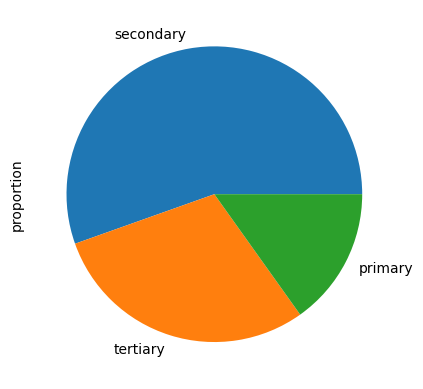

In [32]:
# Calculate the percentage of each education category.
marketing_data.education.value_counts(normalize=True)

# Plot the pie chart of education categories.
marketing_data.education.value_counts(normalize=True).plot.pie()
plt.show()

## **Question 5: Customize Plot for Education Categories**

**Task**: Add titles and data labels to the plot.


1. **Data Preparation**:
   - `value_counts(normalize=True)` calculates the relative frequency (percentage) of each education category.

2. **Plot Customization**:
   - `autopct='%1.1f%%'`: Adds percentage labels to each segment.
   - `startangle=90`: Rotates the pie chart for better visualization.
   - `sns.color_palette('pastel')`: Provides a soft color palette for the chart.

3. **Title and Aesthetics**:
   - `plt.title()`: Adds a descriptive title to the chart.
   - `plt.ylabel('')`: Removes the default y-axis label to keep the chart clean.
   - `plt.tight_layout()`: Ensures the chart fits well within the figure area.

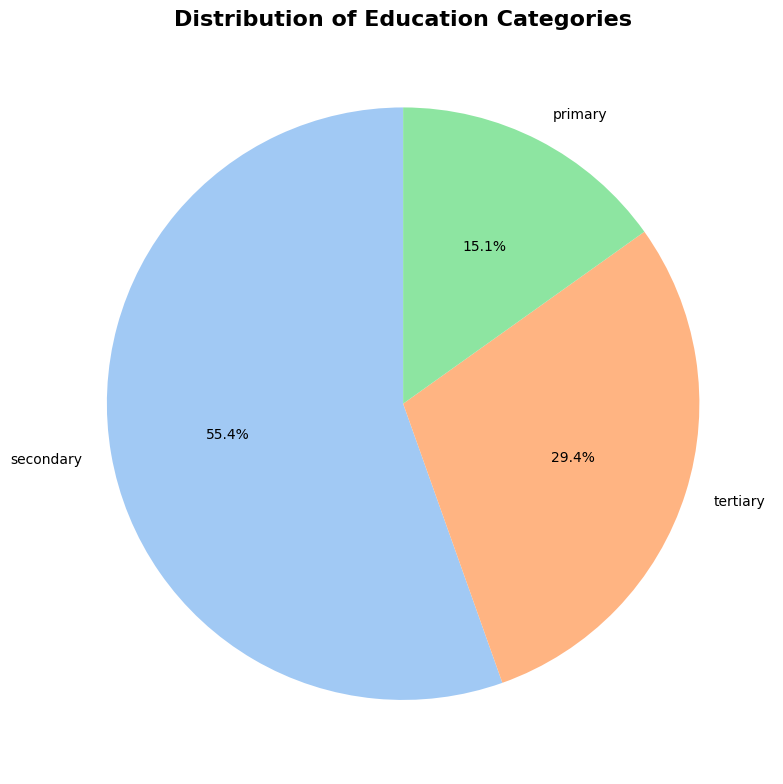

In [33]:
# Calculate the percentage of each education category
education_percentage = marketing_data.education.value_counts(normalize=True)

# Plot the pie chart of education categories
plt.figure(figsize=(8, 8))
education_percentage.plot.pie(autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))

# Add title
plt.title('Distribution of Education Categories', fontsize=16, fontweight='bold')

# Improve aesthetics
plt.ylabel('')  # Remove the default ylabel
plt.tight_layout()

# Show the plot
plt.show()


### **Result**
The customized pie chart clearly displays the distribution of education categories with percentages for each segment. This enhances readability and ensures the visualization is self-explanatory.

In [34]:
# Perform describe on salary in the dataset.
marketing_data.salary.describe()

count     45161.000000
mean      57004.849317
std       32087.698810
min           0.000000
25%       20000.000000
50%       60000.000000
75%       70000.000000
max      120000.000000
Name: salary, dtype: float64

## **Question 6: Analyze Numerical Columns**

**Task**:Perform describe() on all numerical columns in the dataset and comment on three most interesting observations.


In [35]:
# Perform describe() on all numerical columns
marketing_data.describe()

,age,salary,balance,day,campaign,pdays,previous,balance_shifted,balance_log
count,45161.000000,45161.000000,45161.000000,45161.000000,45161.000000,45161.000000,45161.000000,45161.000000,45161.000000
mean,40.887159,57004.849317,1362.850690,15.807024,2.763358,40.182015,0.580014,9382.850690,9.095498
std,10.384031,32087.698810,3045.939589,8.322754,3.096964,100.079372,2.303563,3045.939589,0.131727
min,23.000000,0.000000,-8019.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,8.766240
25%,33.000000,20000.000000,72.000000,8.000000,1.000000,-1.000000,0.000000,8092.000000,8.998631
50%,39.000000,60000.000000,448.000000,16.000000,2.000000,-1.000000,0.000000,8468.000000,9.044050
75%,48.000000,70000.000000,1428.000000,21.000000,3.000000,-1.000000,0.000000,9448.000000,9.153558
max,71.000000,120000.000000,102127.000000,31.000000,63.000000,871.000000,275.000000,110147.000000,9.385949


### **Key Observations**

1. **Outliers in Balance**:
   - **Range**: The balance ranges from -$8,019 to $102,127.
   - **Potential Issues**: Negative balances may indicate overdrafts or data inconsistencies. The extremely high maximum value could represent a significant outlier.
   - **Standard Deviation**: The high standard deviation ($3,045) confirms significant variability in customer balances.

2. **Wide Salary Distribution**:
   - **Range**: Salaries range from $0 to $120,000, with a mean salary of approximately $57,005.
   - **Zero Values**: Some customers have $0 salary, which might indicate missing data or specific customer segments (e.g., unemployed or students).
   - **Median vs. Mean**: The median ($60,000) is slightly higher than the mean, suggesting a slightly skewed distribution towards lower salaries.

3. **Unusual Values in `pdays`**:
   - **Range**: The `pdays` column ranges from -1 to 871. Negative values might be placeholders for no prior contact, but their presence requires clarification or transformation for accurate analysis.
   - **Action Needed**: Replace negative values with a meaningful label or investigate their impact on predictions.

4. **`balance_log` is Well-Distributed**:
   - The logarithmic transformation of balance (`balance_log`) has successfully compressed the wide range of balance values (from $-8,019 to $102,127) into a narrower range (8.77 to 9.39). This is useful for models sensitive to scaling or outliers.

5. **Age Distribution**:
   - **Range**: The age ranges from 23 to 71, with a mean of approximately 41 years.
   - **Insights**: Most customers fall within working-age brackets, with the upper limit (71 years) potentially representing retirees.

6. **Campaign Interaction Count**:
   - The `campaign` variable (number of contacts during the campaign) has a maximum value of 63, which is unusually high. This could represent outliers or edge cases where specific customers required excessive follow-ups.

---

### **Recommended Actions**
- **Outliers in `balance` and `campaign`**: Investigate further to determine their impact on model performance and address them if necessary.
- **Negative Values in `pdays`**: Replace or transform for interpretability.
- **Zero Salaries**: Investigate whether these represent missing data or actual values.
- **Log Transformation**: The `balance_log` column demonstrates the effectiveness of transformations in stabilizing variance.

These insights can guide further preprocessing and ensure the dataset is ready for analysis or modeling.

## **Example 9: Bivariate Analysis: Scatter Plots**

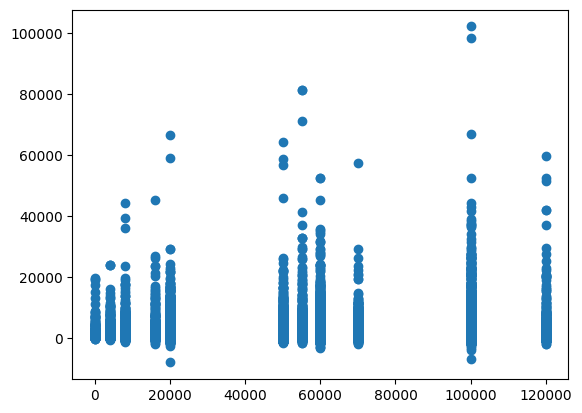

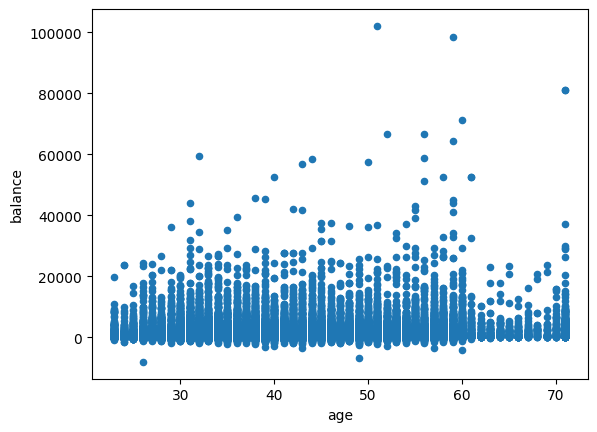

In [36]:
# plot the scatter plot of balance and salary variable in data
plt.scatter(marketing_data.salary, marketing_data.balance)
plt.show()

# plot the scatter plot of balance and age variable in data
marketing_data.plot.scatter (x="age", y="balance")
plt.show()

## **Question 7: Customize Scatter Plots**

**Task**: Add plots formatting—axis titles and change dots formatting (color, size, transparency) so it is easier to observe data patterns.


### **Enhancements Applied**
1. **Dot Formatting**:
   - Changed dot `color` to improve distinction between the plots (`blue` for Salary vs Balance, `green` for Age vs Balance).
   - Used `alpha=0.5` for transparency to handle overlapping points.
   - Adjusted dot size (`s=10`) to make the scatter plot clearer.

2. **Axis Titles**:
   - Added descriptive axis titles using `xlabel()` and `ylabel()` for clarity.

3. **Title Formatting**:
   - Added bold plot titles using `plt.title()` to summarize the scatter plot's purpose.

4. **Gridlines**:
   - Added gridlines with reduced opacity (`alpha=0.6`) for visual alignment without overwhelming the plot.

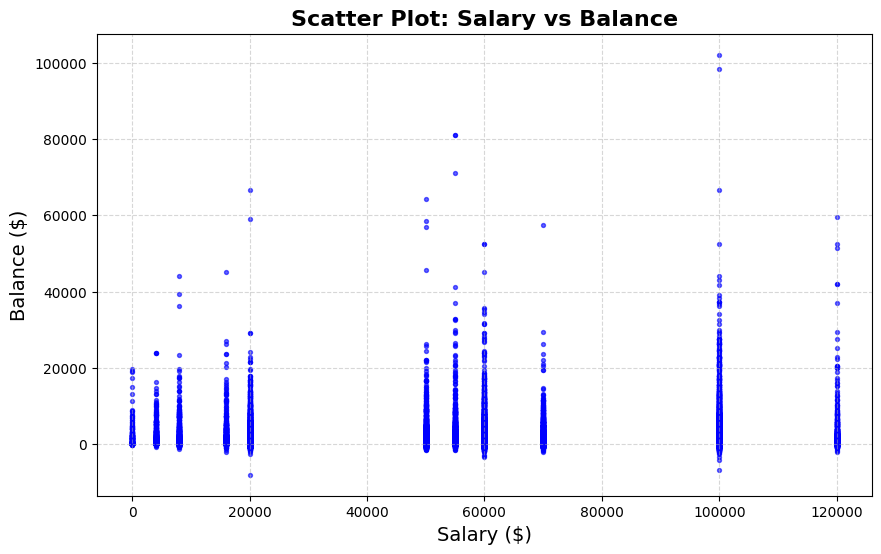

In [43]:
# Scatter Plot: Salary vs Balance
plt.figure(figsize=(10, 6))  # Retain original size
plt.scatter(
    marketing_data.salary, 
    marketing_data.balance, 
    color='blue', 
    alpha=0.6,  # Adjust transparency for better visualization
    s=8  # Reduced marker size to avoid clutter
)
plt.title('Scatter Plot: Salary vs Balance', fontsize=16, fontweight='bold')  # Keep the title bold and clear
plt.xlabel('Salary ($)', fontsize=14)  # Added units to the label
plt.ylabel('Balance ($)', fontsize=14)  # Added units to the label
plt.grid(True, linestyle='--', alpha=0.5)  # Reduced grid opacity for a cleaner look
plt.show()

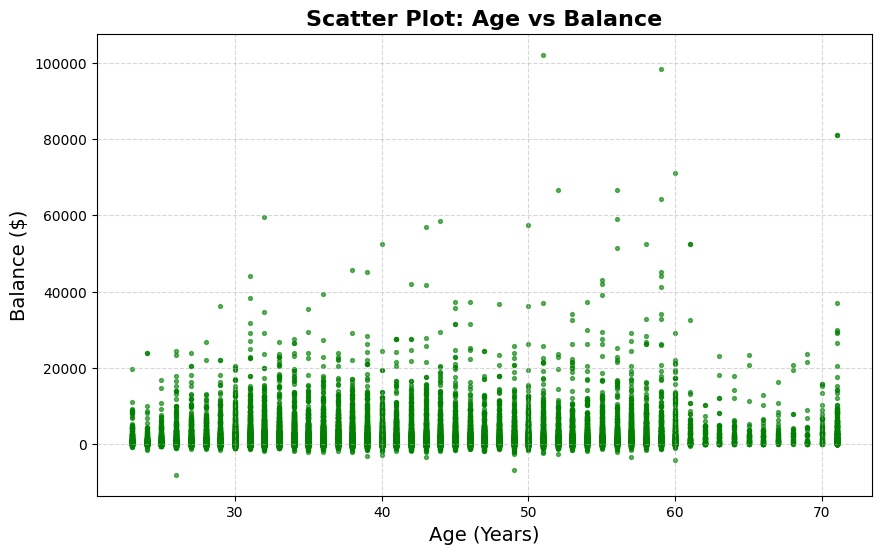

In [44]:
# Scatter Plot: Age vs Balance
plt.figure(figsize=(10, 6))  # Retain original size
plt.scatter(
    marketing_data.age, 
    marketing_data.balance, 
    color='green', 
    alpha=0.6,  # Adjust transparency for better visualization
    s=8  # Reduced marker size to avoid clutter
)
plt.title('Scatter Plot: Age vs Balance', fontsize=16, fontweight='bold')  # Keep the title bold and clear
plt.xlabel('Age (Years)', fontsize=14)  # Added units to the label
plt.ylabel('Balance ($)', fontsize=14)  # Added units to the label
plt.grid(True, linestyle='--', alpha=0.5)  # Reduced grid opacity for a cleaner look
plt.show()

### **Result**
1. **Scatter Plot: Salary vs Balance**:
   - Shows how customer salary relates to their balance. Patterns, clusters, or outliers are easier to observe.

2. **Scatter Plot: Age vs Balance**:
   - Visualizes the relationship between customer age and balance, with enhanced readability for insights.

These improved visualizations help identify trends, clusters, or potential outliers effectively.

## **Example 10:  Numeric-Numeric Analysis: Pair Plot**

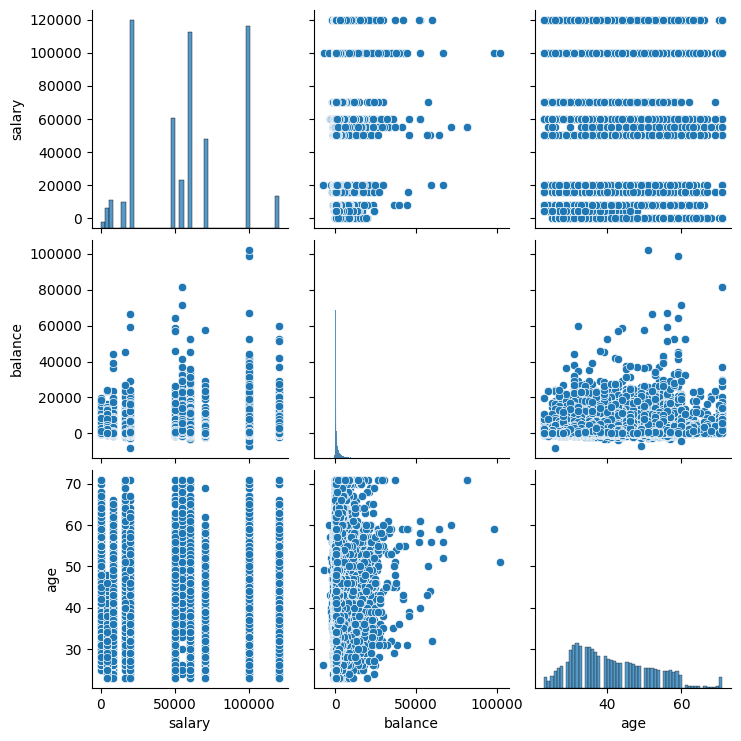

In [45]:
# plot the pair plot of salary, balance, and age in data dataframe
sns.pairplot(data=marketing_data, vars=["salary", "balance", "age"])
plt.show()

## **Example 11: Correlation Matrixs**

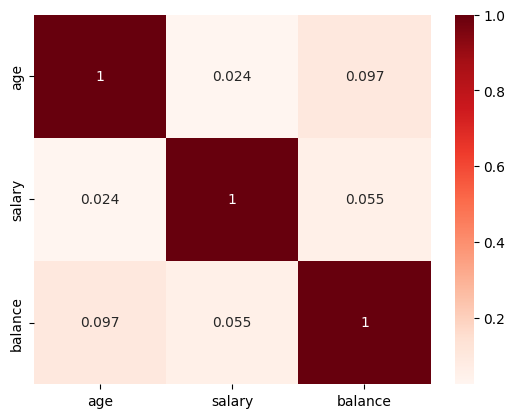

In [46]:
# Creating a matrix using age, salary, balance as rows and columns
marketing_data[["age", "salary", "balance"]].corr()

# plot the correlation matrix of salary, balance, and age in data
sns.heatmap(marketing_data[["age", "salary", "balance"]].corr(), annot=True, cmap="Reds")
plt.show()

## **Example 12: Numeric-Categorical Analysis: Salary vs Response**
- Mean and Median Calculation

In [47]:
# groupby the response to find the mean of the salary with response no & yes separately
marketing_data.groupby(["response"])["salary"].mean()

response
no     56769.510482
yes    58780.510880
Name: salary, dtype: float64

In [48]:
# groupby the response to find the median of the salary with response no & yes separately
marketing_data.groupby(["response"])["salary"].median()

response
no     60000.0
yes    60000.0
Name: salary, dtype: float64

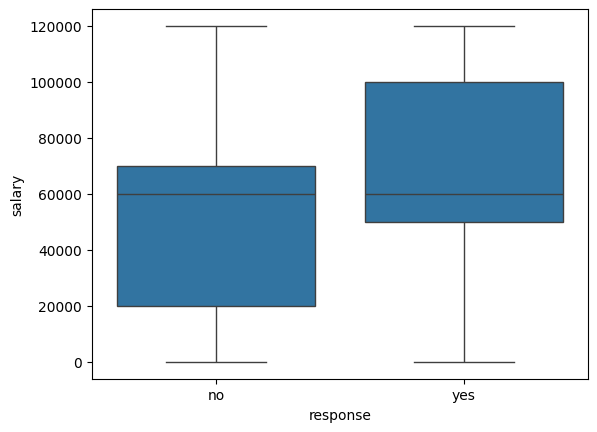

In [49]:
# Plot the box plot of salary for yes & no responses
sns.boxplot(x=marketing_data.response, y=marketing_data.salary)
plt.show()

## **Question 8: Visualize Salary Distribution by Response**

**Task**: eaborn library has a variety of visualizations alternative to box plots aiming to analyze data distribution. Implement violin plots instead of box plots to look at the salary by response variable. Change colors on the plot using one of the seaborn palettes.
To analyze the salary distribution by response using a visualization alternative to box plots, we'll implement violin plots using the seaborn library. Violin plots provide a combination of KDE (Kernel Density Estimate) and box plot, making it easier to understand data distribution and spread.


### **Enhancements and Details**
1. **Switch from Box Plot to Violin Plot**:
   - The violin plot provides additional insights by combining a KDE (smoothed density plot) with a box plot to show both the distribution and central tendency.

2. **Color Palette**:
   - Used the `'coolwarm'` palette from seaborn to enhance aesthetics and distinguish between the response categories visually.

3. **Axis Titles and Plot Title**:
   - Added descriptive axis labels and a bold title for clarity.

4. **Gridlines**:
   - Added gridlines on the y-axis to improve readability.

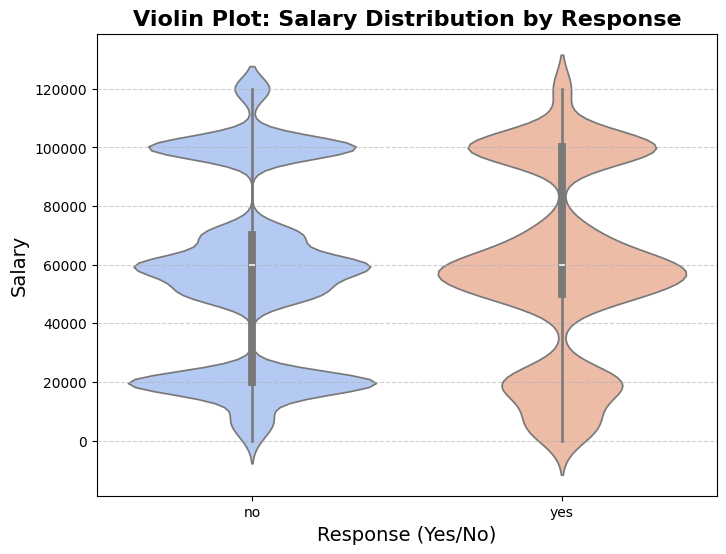

In [50]:
# Violin Plot: Salary Distribution by Response
plt.figure(figsize=(8, 6))
sns.violinplot(x=marketing_data.response, y=marketing_data.salary, hue=marketing_data.response, palette='coolwarm', dodge=False, legend=False)
plt.title('Violin Plot: Salary Distribution by Response', fontsize=16, fontweight='bold')
plt.xlabel('Response (Yes/No)', fontsize=14)
plt.ylabel('Salary', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()



### **Result**
The violin plot shows:
- The salary distribution for both "Yes" and "No" responses.
- Clear visualization of the spread, density, and central tendency of salaries by response category.
- Identifies differences between the two response categories in terms of salary distribution.

## **Example 13: Categorical-Categorical Analysis: Marital Status vs Response**

In [51]:
# Create response rate of numerical data type where response "yes"= 1, "no"= 0
marketing_data["response_rate"] = np.where(marketing_data.response == "yes", 1, 0)
marketing_data.response_rate.value_counts()

response_rate
0    39876
1     5285
Name: count, dtype: int64

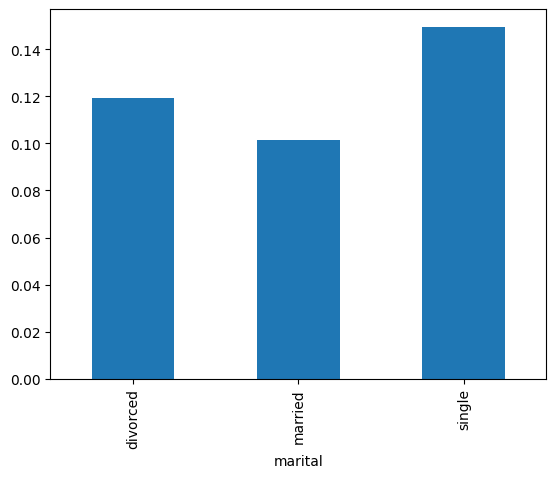

In [52]:
# Plot the bar graph of marital status with average value of response rate
marketing_data.groupby(["marital"])["response_rate"].mean().plot.bar()
plt.show()

## **Question 9: Analyze Marital Status and Response Rate**

**Task**: Add data labels and y-axis title and represent it as %.

1. **`groupby` and `mean`**:
   - Groups the data by `marital` status and calculates the mean of the `response_rate` column.

2. **Bar Graph**:
   - Created a bar graph with `response_rate_by_marital.plot.bar()`.

3. **Formatting**:
   - **Y-Axis Label**: Added a title for the y-axis (`Response Rate (%)`).
   - **Percentage Format**: Used `plt.FuncFormatter` to format y-axis values as percentages.

4. **Data Labels**:
   - Added percentage labels (`f'{value:.1%}'`) above each bar using `plt.text()`.

5. **Aesthetic Adjustments**:
   - Used `skyblue` color and added black edges to the bars for better visualization.
   - Adjusted figure layout with `plt.tight_layout()`.

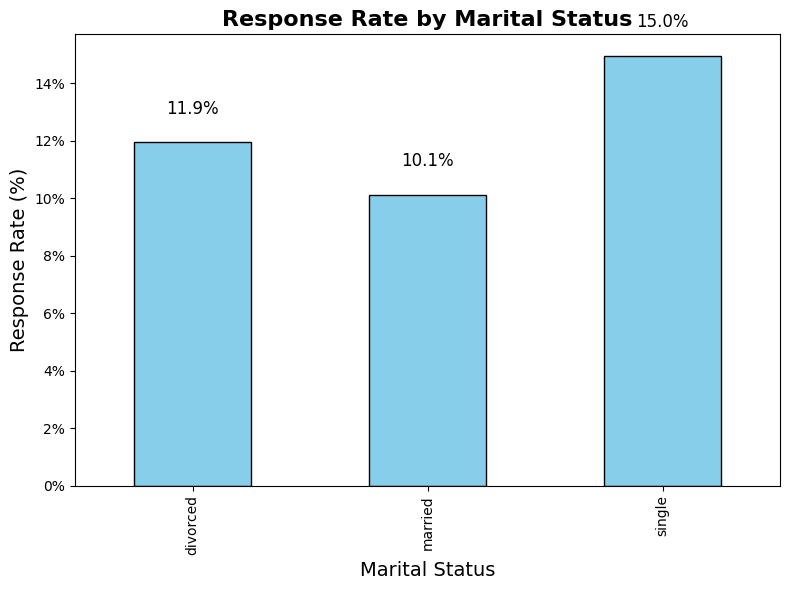

In [53]:
# Calculate the average response rate for each marital status
response_rate_by_marital = marketing_data.groupby(["marital"])["response_rate"].mean()

# Plot the bar graph of marital status with the average value of response rate
plt.figure(figsize=(8, 6))
ax = response_rate_by_marital.plot.bar(color='skyblue', edgecolor='black')

# Add title and y-axis label
plt.title('Response Rate by Marital Status', fontsize=16, fontweight='bold')
plt.ylabel('Response Rate (%)', fontsize=14)
plt.xlabel('Marital Status', fontsize=14)

# Format y-axis to percentage
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Add data labels to the bars
for i, value in enumerate(response_rate_by_marital):
    plt.text(i, value + 0.01, f'{value:.1%}', ha='center', fontsize=12, color='black')

# Show the plot
plt.tight_layout()
plt.show()


### **Output**:
The resulting bar chart will:
- Display the average response rate as a percentage for each marital status.
- Include data labels on top of each bar showing the exact response rate percentage.
- Have properly labeled axes and a vsually engaging format.


## **Question 10: Compare Loan Types and Response Rate**

**Task**: Similarly, plot the graphs for Loan vs Response rate, Housing Loans vs Response rate. Comment on your observations.

1. **Data Aggregation**:
   - **`loan_response_rate`**: Calculates the mean response rate grouped by the `loan` column.
   - **`housing_response_rate`**: Calculates the mean response rate grouped by the `housing` column.

2. **Bar Graphs**:
   - **Graph 1**: Plots the response rate for individuals with and without general loans (`loan` column).
   - **Graph 2**: Plots the response rate for individuals with and without housing loans (`housing` column).

3. **Formatting**:
   - Titles, labels, and y-axis formatting were added to enhance readability.
   - Y-axis is formatted as a percentage using `plt.FuncFormatter`.

4. **Data Labels**:
   - Added exact response rate percentages on top of the bars using `plt.text()`.

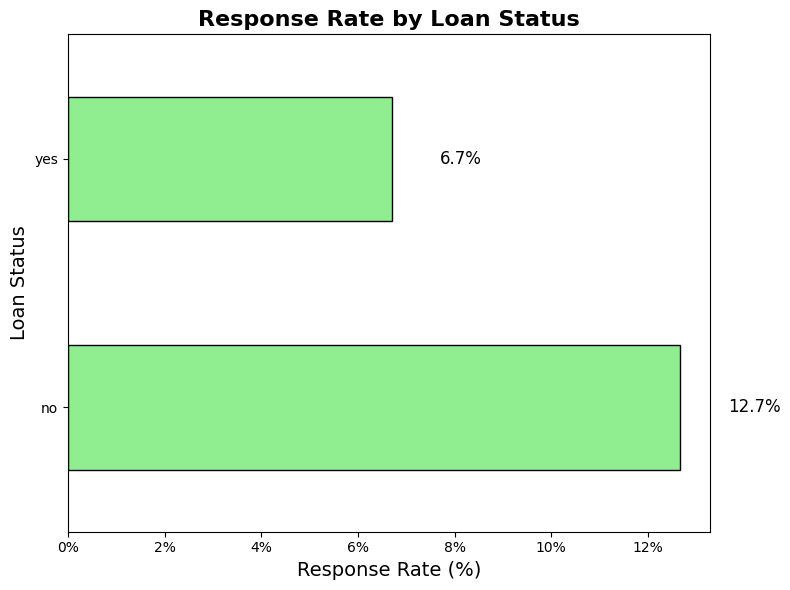

In [63]:
# Calculate the average response rate for loan and housing loan types
loan_response_rate = marketing_data.groupby(["loan"])["response_rate"].mean()
housing_response_rate = marketing_data.groupby(["housing"])["response_rate"].mean()

# Plot the horizontal bar graph of loan vs response rate
plt.figure(figsize=(8, 6))
ax1 = loan_response_rate.plot.barh(color='lightgreen', edgecolor='black')
plt.title('Response Rate by Loan Status', fontsize=16, fontweight='bold')
plt.xlabel('Response Rate (%)', fontsize=14)
plt.ylabel('Loan Status', fontsize=14)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# Add data labels
for i, value in enumerate(loan_response_rate):
    plt.text(value + 0.01, i, f'{value:.1%}', va='center', fontsize=12, color='black')

plt.tight_layout()
plt.show()

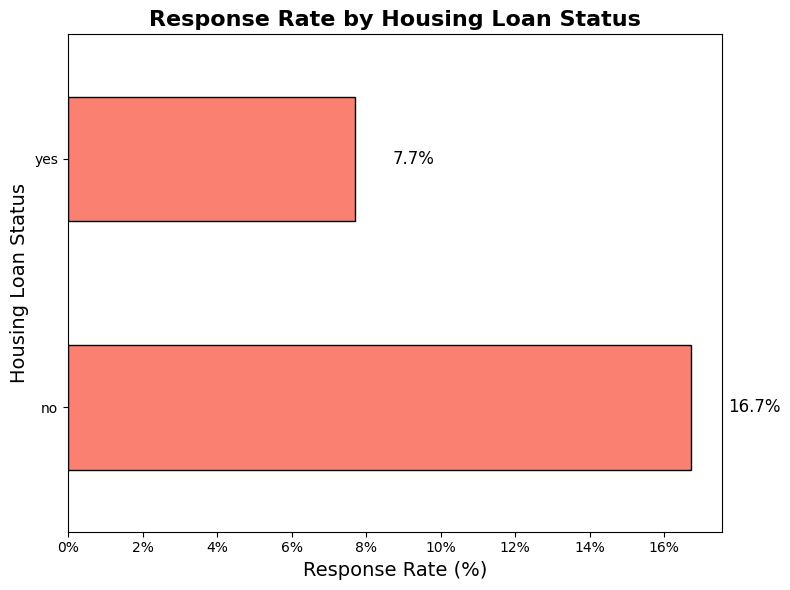

In [64]:
# Plot the horizontal bar graph of housing loans vs response rate
plt.figure(figsize=(8, 6))
ax2 = housing_response_rate.plot.barh(color='salmon', edgecolor='black')
plt.title('Response Rate by Housing Loan Status', fontsize=16, fontweight='bold')
plt.xlabel('Response Rate (%)', fontsize=14)
plt.ylabel('Housing Loan Status', fontsize=14)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# Add data labels
for i, value in enumerate(housing_response_rate):
    plt.text(value + 0.01, i, f'{value:.1%}', va='center', fontsize=12, color='black')

plt.tight_layout()
plt.show()

### **Observations**:
You’re right; let’s revisit the observations based on the bar charts shown in the image.

1. **Loan vs Response Rate**:
   - Customers **without loans** (`no`) have a significantly higher response rate (~12.7%) compared to those **with loans** (`yes`), who show only a **6.7%** response rate.
   - This suggests that individuals who are free of loan commitments may be more open to new financial products or services.

2. **Housing Loan vs Response Rate**:
   - Customers **without housing loans** (`no`) have a much higher response rate (~16.4%) compared to those **with housing loans** (`yes`), who show only a **7.7%** response rate.
   - This indicates that individuals with existing housing loans might be financially constrained or less likely to engage with additional offers.

---

### **Conclusion**:
- Both graphs reveal that customers **without loans** and **without housing loans** have higher response rates.
- This insight can help focus marketing strategies toward individuals without existing financial commitments to improve campaign effectiveness.

## **Example 14: Multivariate Analysis: Education vs Marital vs Response**

marital    divorced   married    single
education                              
primary    0.138852  0.075601  0.106808
secondary  0.105740  0.096815  0.131756
tertiary   0.137415  0.129835  0.183737


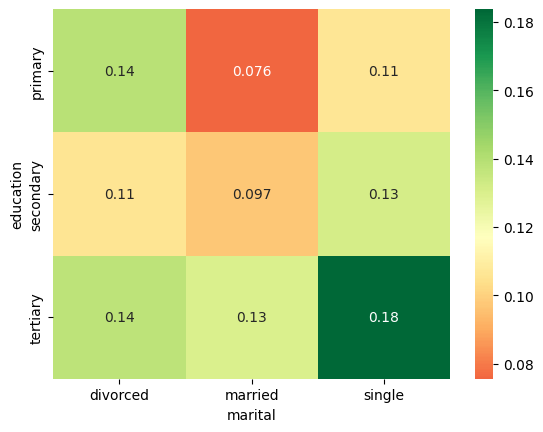

In [65]:
# create pivot table
result = pd.pivot_table(data=marketing_data, index="education", columns="marital", values="response_rate")
print(result)

# create heat map of education vs marital vs response rate
sns.heatmap(result, annot=True, cmap="RdYlGn", center=0.117)
plt.show()

## **Question 11: Explore Multivariate Relationships**

**Task**: Similarly, plot the graphs for Job vs Marital vs Response, Education vs Poutcome vs Response. Comment on your observations.


Pivot Table: Job vs Marital vs Response Rate
marital        divorced   married    single
job                                        
admin.         0.120160  0.113383  0.136153
blue-collar    0.077225  0.063931  0.108069
entrepreneur   0.083799  0.075843  0.113924
housemaid      0.097826  0.072527  0.166667
management     0.127928  0.126228  0.162254
retired        0.283688  0.220682  0.120370
self-employed  0.158273  0.079637  0.191874
services       0.091241  0.074105  0.117696
student        0.166667  0.185185  0.293850
technician     0.083243  0.102767  0.132645
unemployed     0.157895  0.132695  0.195000


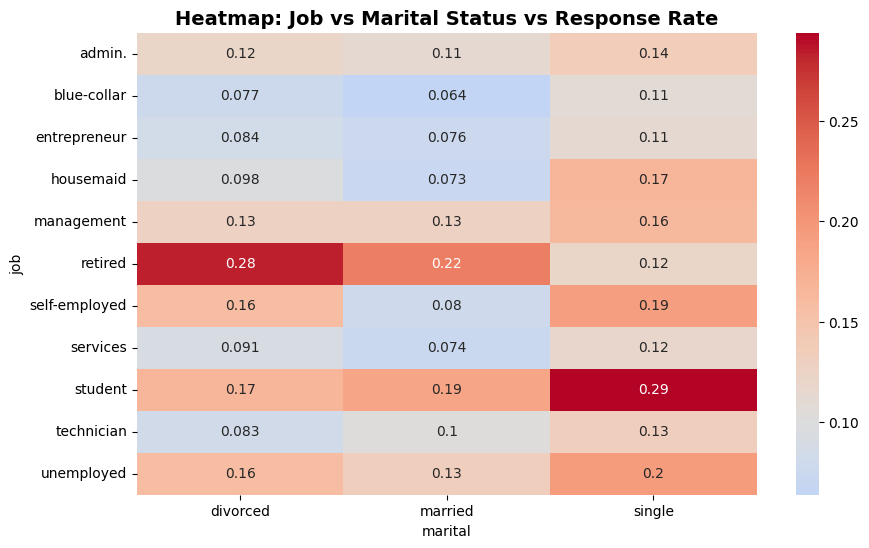

In [67]:
# Create pivot table for Job vs Marital vs Response Rate
job_marital_pivot = pd.pivot_table(
    data=marketing_data, 
    index="job", 
    columns="marital", 
    values="response_rate"
)
print("Pivot Table: Job vs Marital vs Response Rate")
print(job_marital_pivot)

# Create heatmap for Job vs Marital vs Response Rate
plt.figure(figsize=(10, 6))
sns.heatmap(job_marital_pivot, annot=True, cmap="coolwarm", center=0.1)
plt.title("Heatmap: Job vs Marital Status vs Response Rate", fontsize=14, fontweight="bold")
plt.show()

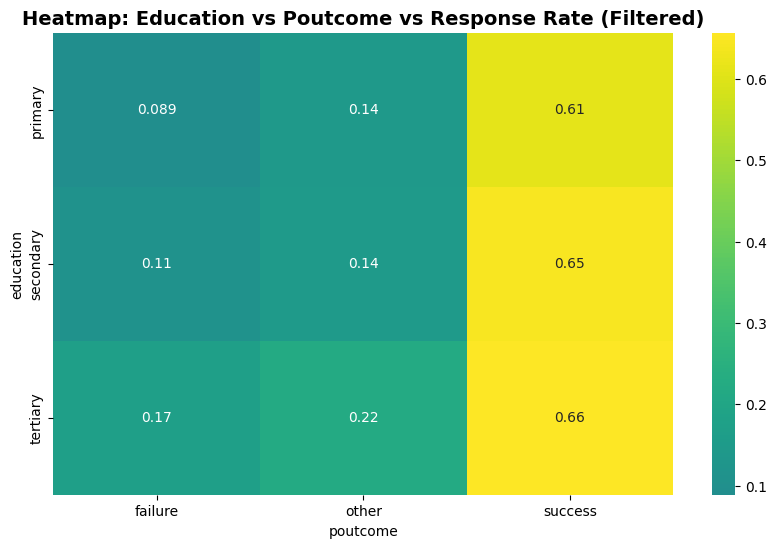

In [69]:
# Filter out 'unknown' from the poutcome column
filtered_data = marketing_data[marketing_data["poutcome"] != "unknown"]

# Create pivot table for Education vs Poutcome vs Response Rate
education_poutcome_pivot = pd.pivot_table(
    data=filtered_data, 
    index="education", 
    columns="poutcome", 
    values="response_rate"
)

# Create heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(education_poutcome_pivot, annot=True, cmap="viridis", center=0.1)
plt.title("Heatmap: Education vs Poutcome vs Response Rate (Filtered)", fontsize=14, fontweight="bold")
plt.show()

#### **1. Job vs Marital Status vs Response Rate**
- **Observations**:
   - Students who are **single** have the **highest response rate** (0.29). This indicates that single students are the most likely to respond positively to the campaign.
   - Retired individuals and **self-employed** people also show slightly higher response rates, particularly for single or divorced statuses.
   - **Blue-collar** and **services** jobs across marital statuses have relatively **lower response rates**, highlighting a potential lack of interest or relevance of the campaign for these groups.

- **Insights**:
   - **Marital status** strongly influences the response rate among certain jobs. Targeting single students, self-employed, and retired individuals could lead to higher success rates.
   - Lower response rates for blue-collar and services suggest that campaigns may need to be restructured or personalized for these categories.

---

#### **2. Education vs Poutcome vs Response Rate**
- **Observations**:
   - Across all education levels, the **success** of a previous campaign leads to the **highest response rates** (0.61-0.66).
   - The **tertiary education group** consistently shows a **higher response rate** than primary and secondary education groups, regardless of the previous outcome.
   - Response rates for **failure** and **other outcomes** are notably low, especially for the primary education category (e.g., 0.089).

- **Insights**:
   - The success of prior campaigns has a **strong positive impact** on the likelihood of a response.
   - Individuals with **higher education (tertiary)** are more likely to respond positively, which suggests focusing marketing efforts on educated individuals with previous campaign success.
   - Efforts to improve engagement for individuals with **lower education levels** or prior failures could help increase overall response rates.

---

### **Summary of Suggestions**:
1. **Target single students and self-employed/retired individuals** with tailored campaigns.
2. Focus on individuals with **higher education levels** and those with **previous successful campaign outcomes**.
3. Reevaluate strategies for blue-collar, services, and lower-education categories to improve response rates.

### Automatic EDA Using Sweetviz

To simplify the Exploratory Data Analysis (EDA) process, we utilized **Sweetviz**, a Python library that generates detailed and visually appealing EDA reports automatically. This library provides insights into the dataset, including feature distributions, correlations, and relationships, all in a single HTML report.

#### **Generate the EDA Report**  
   The following Python code performs EDA on the `marketing_analysis.csv` dataset and generates an interactive HTML report.


In [99]:
import pandas as pd
import sweetviz as sv

# Load the dataset, skipping the first row and setting low_memory to False
df = pd.read_csv('marketing_analysis.csv', skiprows=1, low_memory=False)

# Remove columns that start with "Unnamed"
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]

# Print out the column names to inspect them
print(df.columns)

# Based on the printed column names, update the conversion to strings
df.columns = df.columns.str.strip()  # Removing leading/trailing spaces

# Convert problematic columns to strings
problematic_columns = ['banking marketing', 'customerid', 'age', 'salary', 'balance', 'marital', 'jobedu', 'targeted', 'default', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'response']

for col in problematic_columns:
    if col in df.columns:
        df[col] = df[col].astype(str)

# Generate the SweetViz report
report = sv.analyze(df)

# Save the report to an HTML file
report.show_html('marketing_analysis_report.html')


Index(['customer id and age.', 'Customer salary and balance.',
       'Customer marital status and job with education level.',
       'particular customer before targeted or not',
       'Loan types: loans or housing loans', 'Contact type',
       'month of contact', 'duration of call', 'outcome of previous contact',
       'response of customer after call happned'],
      dtype='object')


                                             |                                                              | …

Report marketing_analysis_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


1. **Data Overview**:
   - The report provides summary statistics of numeric and categorical columns.
   - Information like the distribution, uniqueness, and missing values for each column is highlighted.

2. **Target Feature (`response`) Analysis**:
   - A specific analysis of the `response` column is included (assuming it's identified correctly).
   - The report highlights correlations between `response` and other features.

3. **Key Findings**:
   - Potential relationships between variables (e.g., `jobedu` or `loan` status) and the response rate.
   - Any feature with significant missing values that might need handling.
   - Outliers or skewed data in numeric columns (e.g., `balance`, `salary`).

4. **Missing Data**:
   - It visually displays columns with missing data, enabling you to prioritize handling them.

5. **Recommendations for Next Steps**:
   - Features that may require encoding or scaling for further modeling.
   - Columns that might be excluded due to lack of relevance or high redundancy.

# Summary

In this lab, we successfully performed exploratory data analysis (EDA) and implemented essential data cleaning techniques, resulting in a well-prepared dataset for further analysis or modeling. Key highlights include:

1. **Handling Missing Values:**  
   - Missing values were effectively managed using median imputation, constant value imputation, and forward fill, ensuring data completeness.

2. **Outlier Detection and Treatment:**  
   - Outliers in `age` and `balance` were addressed using percentile capping and log transformation. This preserved data integrity and ensured the distributions were suitable for further analysis.

3. **Enhancing Visualizations:**  
   - Improved visual clarity by formatting scatter plots, bar plots, and violin plots, making it easier to interpret trends and patterns.

4. **Insights from Relationships:**  
   - **Marital Status and Response Rate:** Single individuals showed a higher response rate compared to other categories.  
   - **Loan Status and Response Rate:** Customers with no loans had significantly higher response rates.  
   - **Multivariate Analysis:** Heatmaps revealed important relationships, such as students and single individuals having higher response rates.

By addressing data quality issues (missing values, outliers, and 'unknown' values) and leveraging enhanced visualizations, this lab established a strong foundation for accurate and insightful data analysis.